# Task 3: Correlation Between News Sentiment and Stock Movement

## Objective
This notebook analyzes the relationship between financial news sentiment and stock market returns.

The analysis includes:
- Date alignment between news and stock datasets
- Sentiment scoring using NLP
- Daily stock return calculation
- Correlation analysis
- Visualization of sentiment vs stock performance

## Import Required Libraries

We import pandas, numpy, TextBlob, matplotlib, and seaborn for sentiment analysis, data manipulation, and visualization.

In [1]:
import pandas as pd
import numpy as np

from textblob import TextBlob

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr

## Load News and Stock Datasets

We load:
- Financial news headline dataset
- Historical stock price dataset

In [4]:
news_df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")
stock_df = pd.read_csv("../data/raw/AAPL.csv")

news_df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


## Prepare News Dataset

We convert publication dates into datetime format and extract trading dates.

In [6]:
news_df["date"] = pd.to_datetime(
    news_df["date"],
    format="mixed",
    utc=True
)

news_df["trading_date"] = news_df["date"].dt.date


news_df[["headline", "trading_date"]].head()

,headline,trading_date
0,Stocks That Hit 52-Week Highs On Friday,2020-06-05
1,Stocks That Hit 52-Week Highs On Wednesday,2020-06-03
2,71 Biggest Movers From Friday,2020-05-26
3,46 Stocks Moving In Friday's Mid-Day Session,2020-05-22
4,B of A Securities Maintains Neutral on Agilent...,2020-05-22


## Prepare Stock Dataset

We convert stock dates into datetime format and compute daily percentage returns.

In [7]:
stock_df["Date"] = pd.to_datetime(stock_df["Date"])

stock_df["Daily_Return"] = (
    stock_df["Close"].pct_change() * 100
)

stock_df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,NaN
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,4.220416
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,-1.649399
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,-2.160860
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,1.856959


## Sentiment Analysis Using TextBlob

TextBlob is used to assign polarity scores to financial news headlines.

Sentiment score interpretation:
- Positive score → Positive sentiment
- Negative score → Negative sentiment
- Near zero → Neutral sentiment

In [8]:
def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

news_df["sentiment_score"] = news_df["headline"].apply(get_sentiment)

news_df[["headline", "sentiment_score"]].head()

,headline,sentiment_score
0,Stocks That Hit 52-Week Highs On Friday,0.0
1,Stocks That Hit 52-Week Highs On Wednesday,0.0
2,71 Biggest Movers From Friday,0.0
3,46 Stocks Moving In Friday's Mid-Day Session,0.0
4,B of A Securities Maintains Neutral on Agilent...,0.0


## Aggregate Daily Sentiment Scores

If multiple articles exist for the same day, we calculate the average sentiment score.

In [9]:
daily_sentiment = (
    news_df.groupby("trading_date")["sentiment_score"]
    .mean()
    .reset_index()
)

daily_sentiment.head()

,trading_date,sentiment_score
0,2009-02-14,0.000000
1,2009-04-27,0.000000
2,2009-04-29,0.000000
3,2009-05-22,0.000000
4,2009-05-27,0.234091


## Align News and Stock Dates

We merge average daily sentiment scores with stock daily returns using trading dates.

In [10]:
stock_df["trading_date"] = stock_df["Date"].dt.date

merged_df = pd.merge(
    daily_sentiment,
    stock_df[["trading_date", "Daily_Return"]],
    on="trading_date",
    how="inner"
)

merged_df.head()

,trading_date,sentiment_score,Daily_Return
0,2009-04-27,0.000000,0.669876
1,2009-04-29,0.000000,1.000849
2,2009-05-22,0.000000,-1.352902
3,2009-05-27,0.234091,1.735764
4,2009-05-29,0.068182,0.547854


## Pearson Correlation Analysis

We calculate the Pearson correlation coefficient between:
- Average daily sentiment score
- Daily stock returns

In [11]:
correlation, p_value = pearsonr(
    merged_df["sentiment_score"],
    merged_df["Daily_Return"]
)

print("Correlation:", correlation)
print("P-value:", p_value)

Correlation: 0.043939250895886975
P-value: 0.02104409018024318


## Sentiment vs Stock Return Scatter Plot

This visualization shows the relationship between news sentiment and stock returns.

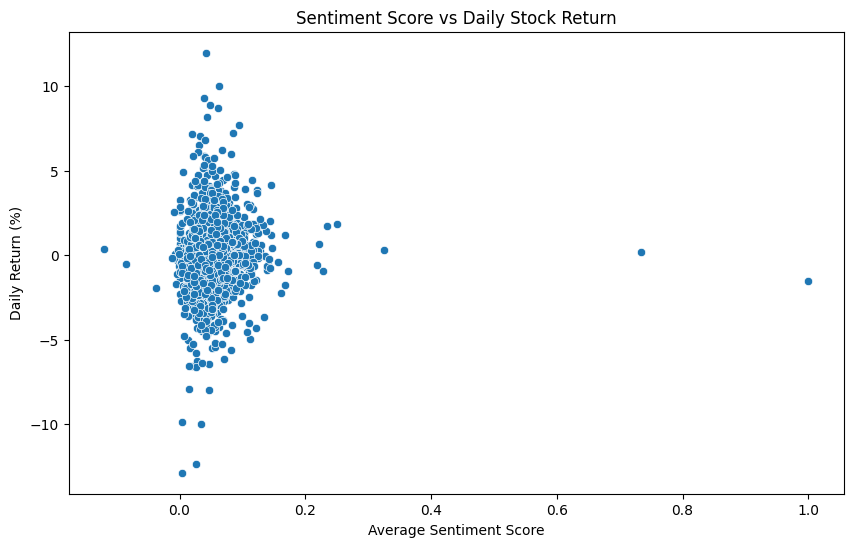

In [12]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged_df,
    x="sentiment_score",
    y="Daily_Return"
)

plt.title("Sentiment Score vs Daily Stock Return")
plt.xlabel("Average Sentiment Score")
plt.ylabel("Daily Return (%)")

plt.show()

## Sentiment Category Classification

Days are classified into:
- Positive
- Neutral
- Negative

In [13]:
def classify_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

merged_df["Sentiment_Category"] = merged_df[
    "sentiment_score"
].apply(classify_sentiment)

merged_df.head()

,trading_date,sentiment_score,Daily_Return,Sentiment_Category
0,2009-04-27,0.000000,0.669876,Neutral
1,2009-04-29,0.000000,1.000849,Neutral
2,2009-05-22,0.000000,-1.352902,Neutral
3,2009-05-27,0.234091,1.735764,Positive
4,2009-05-29,0.068182,0.547854,Positive


## Average Daily Return by Sentiment Category

We compare stock returns across positive, neutral, and negative news days.

In [14]:
category_returns = (
    merged_df.groupby("Sentiment_Category")[
        "Daily_Return"
    ]
    .mean()
    .reset_index()
)

category_returns

,Sentiment_Category,Daily_Return
0,Negative,-0.229689
1,Neutral,0.850159
2,Positive,0.119719


## Bar Chart Visualization

This chart shows average stock returns for each sentiment category.

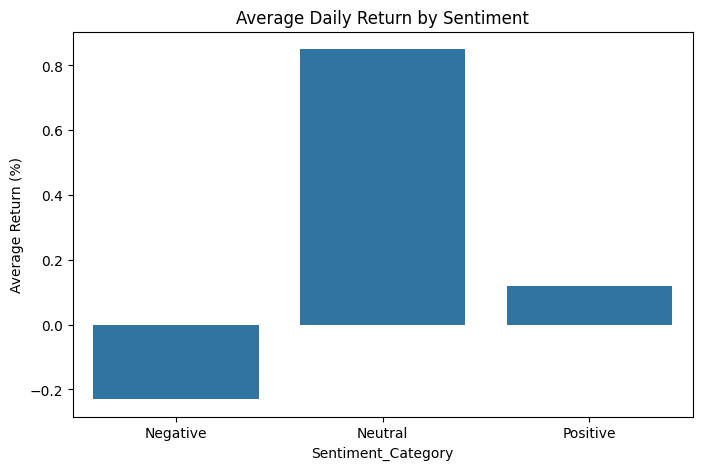

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=category_returns,
    x="Sentiment_Category",
    y="Daily_Return"
)

plt.title("Average Daily Return by Sentiment")
plt.ylabel("Average Return (%)")

plt.show()

# Interpretation of Results

The Pearson correlation coefficient measures the relationship between news sentiment and stock returns.

A positive correlation suggests that positive news sentiment is associated with positive stock returns, while a negative correlation indicates the opposite relationship.

The scatter plot helps visualize whether a linear relationship exists between sentiment and market performance.

Limitations of this analysis include:
- News may impact markets with delays
- External macroeconomic events can affect prices
- Sentiment tools may misinterpret financial language
- Correlation does not imply causation